Inicialización del entorno de trabajo. Importamos la librería pandas y procedemos a cargar el dataset housing.csv en un objeto DataFrame. Este paso es fundamental para poder aplicar las operaciones de análisis y transformación posteriores.

In [23]:
import pandas as pd
datos = pd.read_csv('housing.csv')

Inspección inicial de la estructura. Empleamos el método head() para visualizar un extracto de las primeras filas del conjunto de datos. Esto nos permite comprender la disposición de las columnas, los tipos de datos preliminares y el formato de los valores, estableciendo una base para el análisis exploratorio.

In [24]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Análisis de frecuencias de una variable categórica. Aplicamos value_counts() a la serie ocean_proximity para obtener la distribución de frecuencias absolutas de cada categoría. Este conteo es esencial para entender la composición geográfica de los registros y detectar posibles desbalances en los datos.

In [25]:
datos["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Diagnóstico general del DataFrame. Utilizamos info() para obtener un informe detallado que incluye el número de entradas no nulas por columna, el tipo de dato (dtype) de cada una y el consumo de memoria total. Este diagnóstico es crucial para identificar valores faltantes y validar la integridad de los tipos de datos.



In [26]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Resumen estadístico descriptivo. A través de describe(), generamos un cuadro que resume las principales medidas de tendencia central (media, mediana), dispersión (desviación estándar) y rango (mínimo, máximo) para las variables numéricas. Este análisis nos da una visión cuantitativa de la distribución y escala de los datos.



In [27]:
datos.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Visualización de distribuciones univariantes. Empleamos el método hist() para construir una matriz de histogramas que muestran la frecuencia de los valores para cada atributo numérico. Esta representación gráfica nos permite inspeccionar visualmente la asimetría, la presencia de valores atípicos y la forma general de las distribuciones.



array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

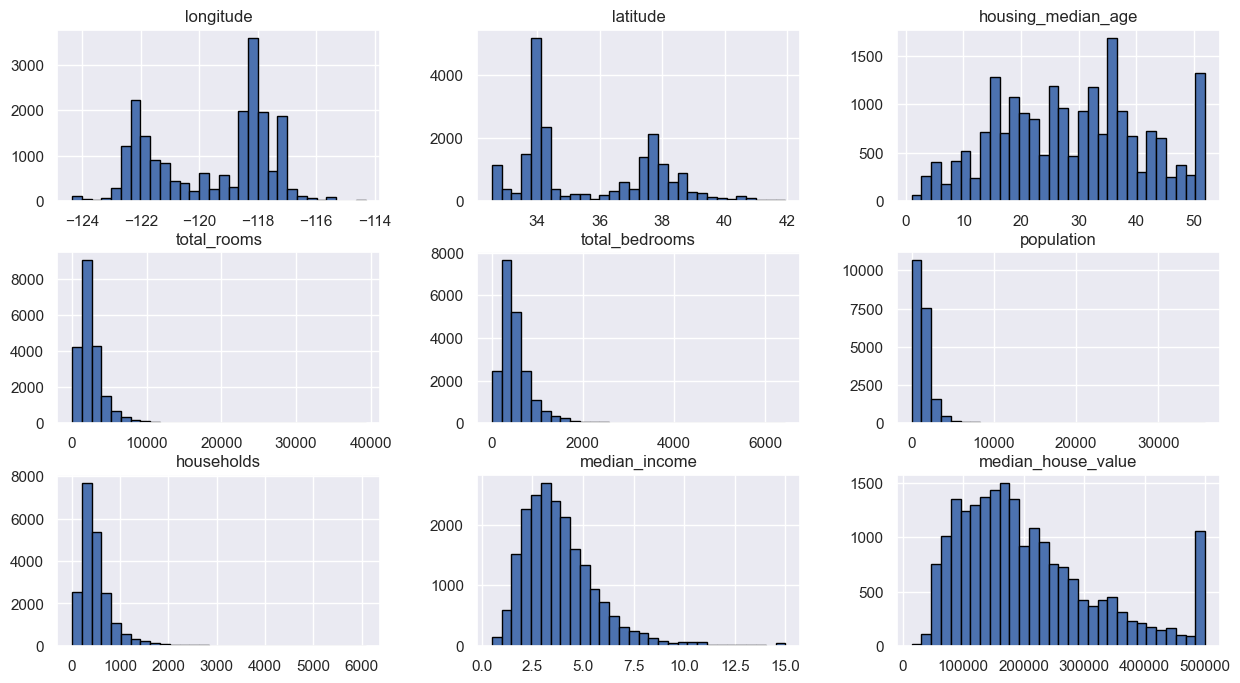

In [28]:
datos.hist(figsize=(15, 8), bins = 30, edgecolor='black')

Exploración de relaciones geoespaciales y económicas. Utilizando seaborn, construimos un gráfico de dispersión que mapea la latitud y longitud de las propiedades. El color de los puntos representa el valor de la vivienda y el tamaño, la población. Esta visualización es clave para identificar patrones de precios y densidad demográfica en las diferentes regiones.



TypeError: cannot convert the series to <class 'float'>

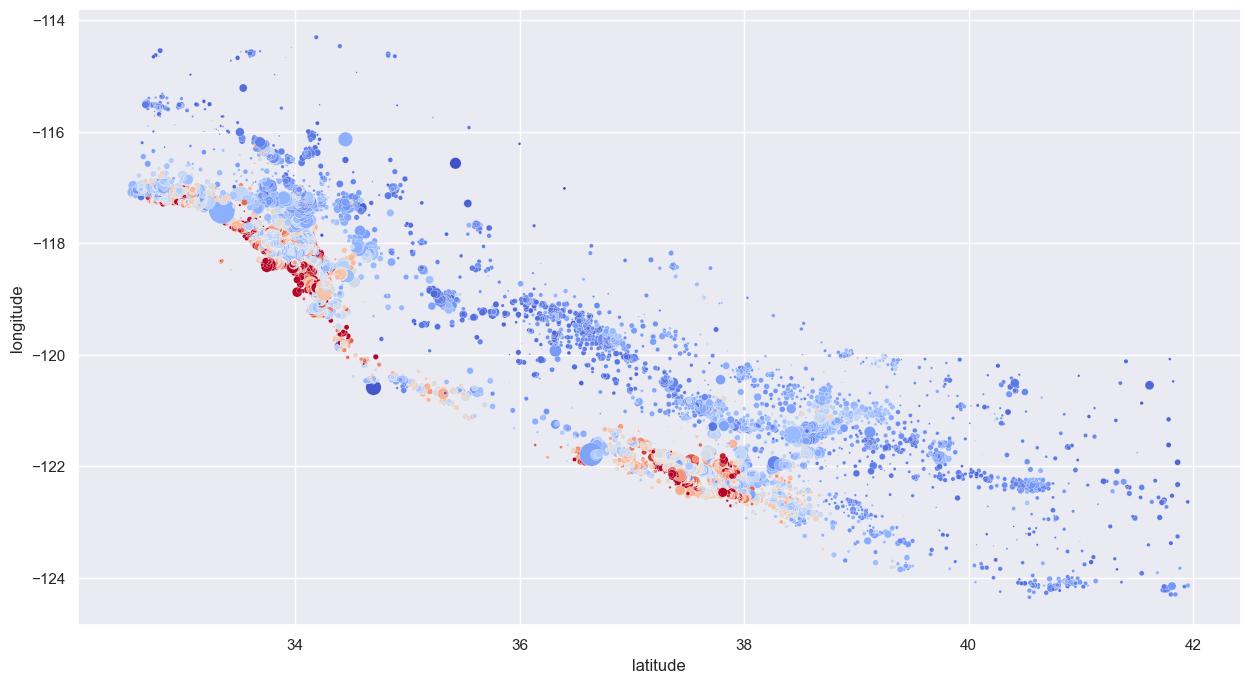

In [29]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value", palette="coolwarm",
s=datos["population"]/100)

Revisión de la estructura del dataset. Ejecutamos nuevamente info() para obtener un panorama actualizado de la integridad de los datos, confirmando la ausencia de valores nulos después de las transformaciones previas. El resumen también verifica la correcta conversión de los tipos de datos.



In [31]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Limpieza de datos: eliminación de registros incompletos. Aplicamos dropna() para generar un nuevo DataFrame, datos_na, que excluye cualquier fila que contenga un valor nulo. Este proceso asegura que los análisis posteriores se realicen sobre un conjunto de datos completo, evitando sesgos por datos ausentes.



In [32]:
datos_na = datos.dropna()

Verificación de la limpieza. Al llamar a info() sobre datos_na, confirmamos que el proceso de eliminación de filas con valores nulos ha sido exitoso, evidenciando ahora un conteo de registros no nulos consistente en todas las columnas. Esto valida la integridad del dataset limpio.



In [33]:
datos_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


Examen de la variable categórica. Seleccionamos la columna ocean_proximity para inspeccionar sus valores únicos y su formato. Este paso preliminar es necesario antes de aplicar técnicas de codificación que conviertan esta variable en un formato numérico adecuado para modelos de machine learning.



In [34]:
#convertir la caracteristica categorica a numerica
#Proximidad al oceano
datos_na['ocean_proximity']

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20433, dtype: object

Cuantificación de categorías. Usamos value_counts() para obtener un recuento preciso de la ocurrencia de cada tipo de proximidad al océano. Estos conteos son fundamentales para evaluar la representatividad de las categorías y para decidir si es necesario realizar un balanceo de datos.



In [35]:
datos_na['ocean_proximity'].value_counts()
#1,2,3,4,5

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

Codificación de variables categóricas. Aplicamos la técnica de one-hot encoding mediante get_dummies() para transformar la columna ocean_proximity en un conjunto de variables binarias (dummies). Este proceso es estándar para convertir información categórica en un formato numérico utilizable por algoritmos de aprendizaje automático.



In [36]:
#Dumies / One-Hot Encoding
# NEAR BAY  INLAND  NEAR OCEAN
#   0          0         1
dummies = pd.get_dummies(datos_na["ocean_proximity"], dtype=int)


Integración de variables transformadas. Incorporamos las nuevas columnas binarias resultantes del one-hot encoding al DataFrame datos_na utilizando join(). De esta forma, enriquecemos el dataset con representaciones numéricas de la variable categórica original, manteniendo la coherencia de los datos.



In [37]:
datos_na = datos_na.join(dummies)

Validación post-transformación. Inspeccionamos con head() las primeras filas del dataset modificado para confirmar la correcta adición de las nuevas columnas dummies. Esta verificación visual asegura que el proceso de codificación se ha aplicado sin errores.





In [38]:
datos_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,0,1,0


Purga de la variable categórica original. Procedemos a eliminar la columna ocean_proximity mediante drop(). Una vez que sus categorías han sido representadas por las variables dummy, retirar la columna original evita redundancia y posibles multicolinealidades en el análisis.



In [39]:
datos_na = datos_na.drop(["ocean_proximity"], axis=1)

Confirmación de la estructura final. Visualizamos las primeras filas del DataFrame resultante para corroborar que el conjunto de datos ahora consta exclusivamente de atributos numéricos, listo para la fase de modelado o análisis multivariante.



In [40]:
datos_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [41]:
#Analisis, nuevas caracteristicas

Análisis de interdependencias numéricas. Construimos un mapa de calor utilizando seaborn sobre la matriz de correlación (corr()) del dataset. Este gráfico permite identificar rápidamente pares de variables con alta correlación positiva o negativa, lo cual es fundamental para entender las relaciones intrínsecas entre los atributos y para la selección de características.



<Axes: >

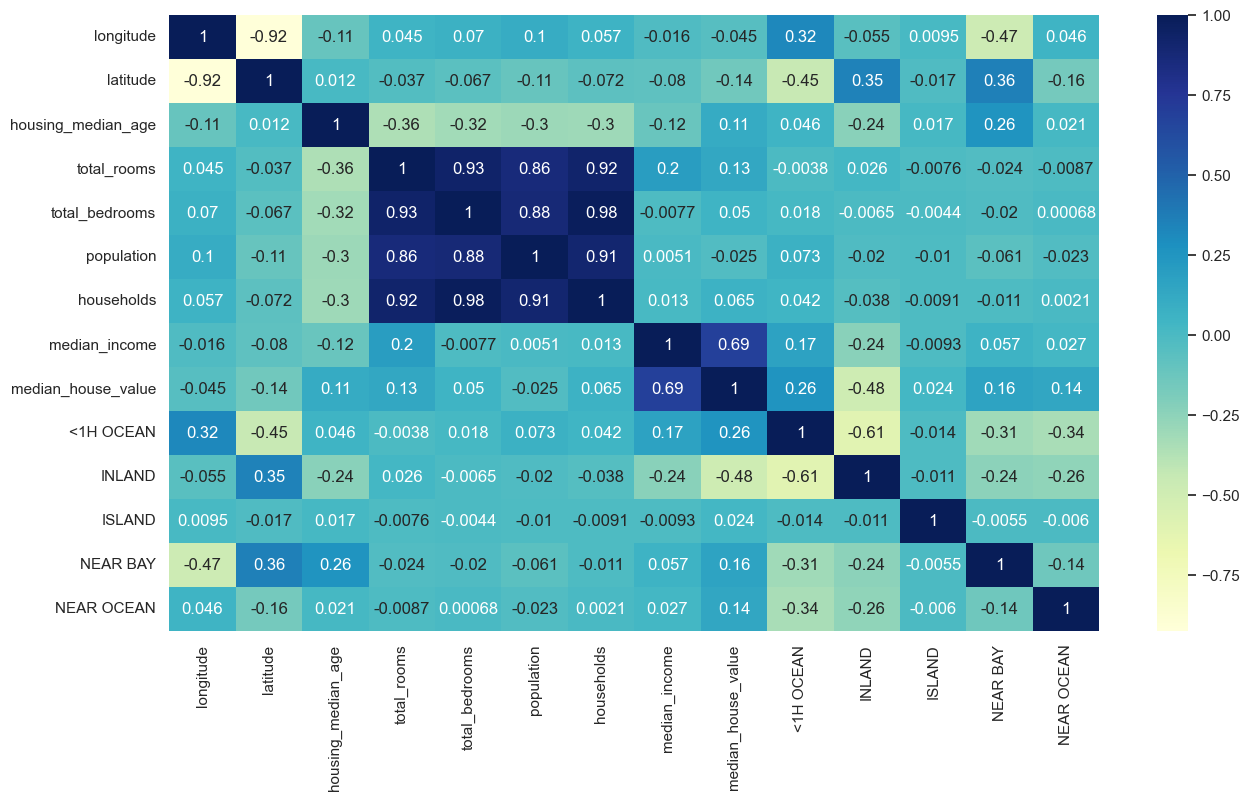

In [42]:
sb.set(rc={'figure.figsize':(15, 8)})
sb.heatmap(datos_na.corr(), annot=True, cmap="YlGnBu")

Análisis de correlación con la variable objetivo. Calculamos la matriz de correlación y extraemos los coeficientes de correlación de todas las características con respecto a 'median_house_value', ordenándolos de mayor a menor. Esto nos permite identificar rápidamente qué variables tienen una relación lineal más fuerte con el valor de la vivienda, siendo el ingreso mediano (median_income) el predictor más influyente con una correlación positiva de aproximadamente 0.69.

In [43]:
datos_na.corr()["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688355
<1H OCEAN             0.257614
NEAR BAY              0.160526
NEAR OCEAN            0.140378
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
ISLAND                0.023525
population           -0.025300
longitude            -0.045398
latitude             -0.144638
INLAND               -0.484787
Name: median_house_value, dtype: float64

Visualización de la relación entre ingreso y valor de vivienda. Creamos un diagrama de dispersión (scatter plot) con seaborn para explorar visualmente la relación entre el ingreso mediano (eje Y) y el valor mediano de la vivienda (eje X). Esta gráfica confirma la correlación positiva observada en el análisis anterior: a mayor ingreso, mayor tiende a ser el valor de la propiedad. La nube de puntos muestra una tendencia ascendente, aunque con dispersión considerable, lo que sugiere que otros factores también influyen en el precio de las viviendas.

<Axes: xlabel='median_house_value', ylabel='median_income'>

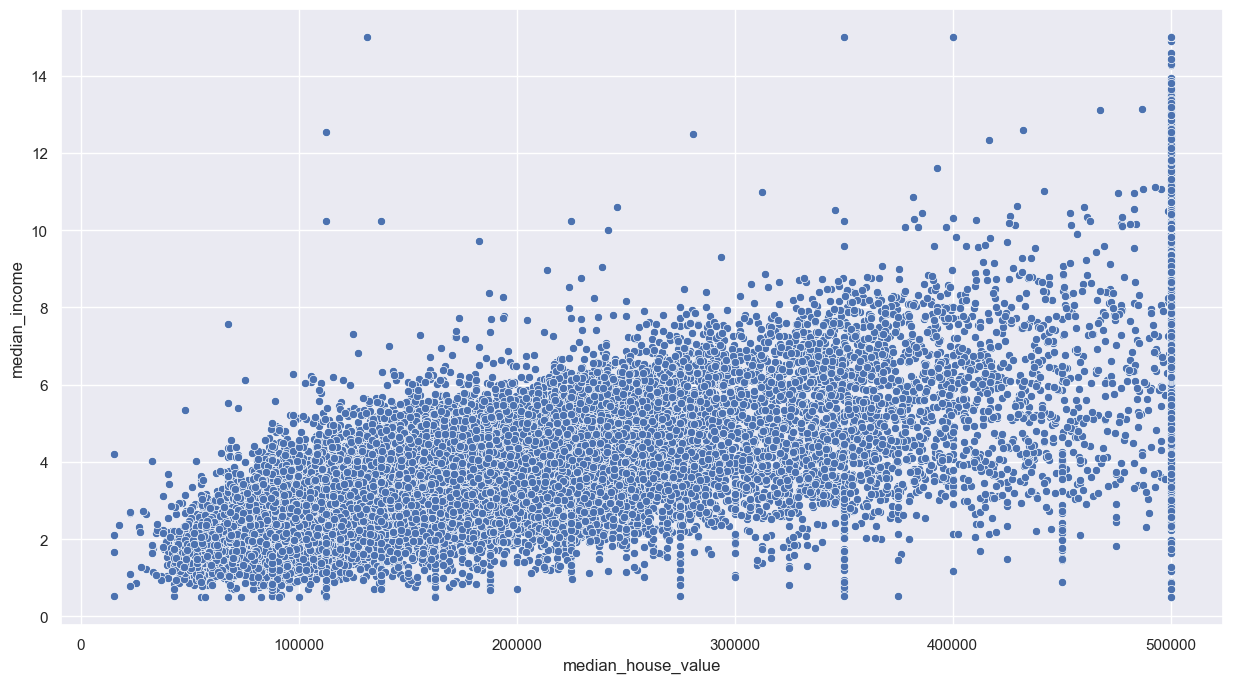

In [45]:
sb.scatterplot(x=datos_na["median_house_value"], y=datos_na["median_income"])

Creación de una nueva característica: ratio de habitaciones. Generamos una nueva columna 'bedroom_ratio' que representa la proporción de dormitorios respecto al total de habitaciones. Esta ingeniería de características permite capturar la densidad de dormitorios por vivienda, un indicador que podría estar relacionado con el valor de la propiedad. Al dividir total_bedrooms entre total_rooms, obtenemos un valor entre 0 y 1 que normaliza esta relación independientemente del tamaño absoluto de la vivienda.

In [46]:
datos_na["bedroom_ratio"] = datos_na["total_bedrooms"] / datos_na["total_rooms"]

Visualización de la matriz de correlación completa. Configuramos el tamaño de la figura para mejorar la legibilidad y generamos un mapa de calor (heatmap) que muestra todos los coeficientes de correlación entre las variables del dataset. Los valores están anotados en cada celda (annot=True) y utilizamos la paleta de colores "YlGnBu" (amarillo-verde-azul) para representar la intensidad de la correlación. Los tonos más oscuros indican correlaciones más fuertes, permitiendo identificar visualmente patrones como la alta correlación positiva entre total_rooms, total_bedrooms, population y households, así como la correlación negativa entre INLAND y median_house_value.

<Axes: >

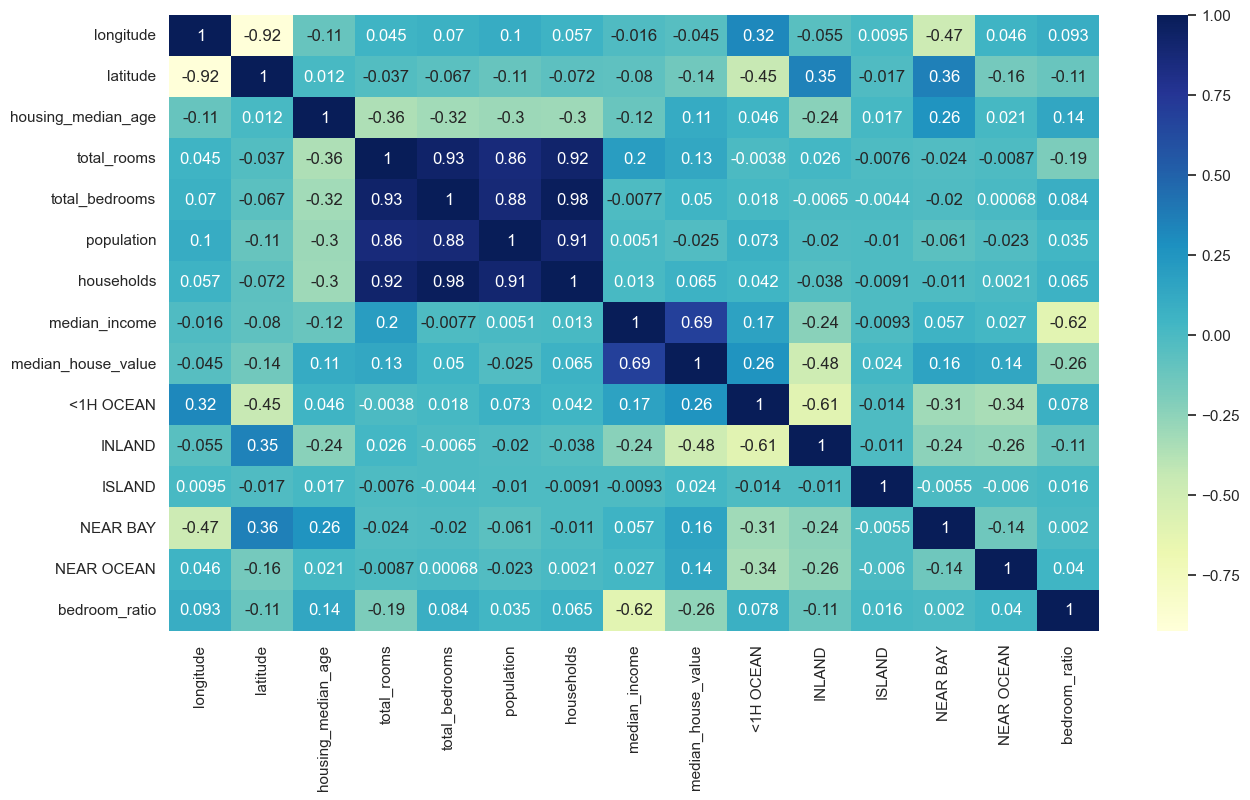

In [47]:
sb.set(rc={'figure.figsize':(15, 8)})
sb.heatmap(datos_na.corr(), annot=True, cmap="YlGnBu")

Separación de características y variable objetivo. Dividimos el dataset en dos componentes fundamentales para el modelado: X, que contiene todas las variables predictoras (características), obtenidas eliminando la columna 'median_house_value'; y y, que contiene la variable objetivo que deseamos predecir. Esta separación es un paso previo esencial antes de entrenar cualquier modelo de aprendizaje automático, permitiendo que el algoritmo aprenda la relación entre las características de entrada y el valor de salida.

In [48]:

#separar las carateristicas de la etiqueta
X = datos_na.drop("median_house_value", axis=1)
y = datos_na["median_house_value"]

División en conjuntos de entrenamiento y prueba. Utilizamos train_test_split de scikit-learn para particionar los datos en dos subconjuntos: el conjunto de entrenamiento (80% de los datos) que se utilizará para ajustar el modelo, y el conjunto de prueba (20% restante) que servirá para evaluar su rendimiento con datos no vistos. Esta estrategia es fundamental para detectar posibles problemas de sobreajuste (overfitting) y garantizar que el modelo generaliza correctamente a nuevas observaciones.

In [49]:
#separar los datos en 2 partes: cConjunto de entrenamiento y uno de pruebas
from sklearn.model_selection import train_test_split
X_ent, X_pru, y_ent, y_pru = train_test_split(X,y, test_size=.2)

Inicialización del modelo de regresión lineal. Instanciamos un objeto LinearRegression de scikit-learn, que implementa el algoritmo de regresión lineal ordinaria por mínimos cuadrados. Este modelo establecerá una relación lineal entre las características de entrada (X) y la variable objetivo (y), buscando los coeficientes que minimicen la suma de los errores cuadráticos entre los valores predichos y los reales.

In [ ]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()

Entrenamiento del modelo. Ajustamos el modelo de regresión lineal utilizando los datos de entrenamiento. Durante este proceso, el algoritmo calcula los coeficientes óptimos para cada característica, determinando la contribución de cada variable en la predicción del valor de la vivienda. Internamente, se resuelve la ecuación matricial que minimiza el error cuadrático medio entre los valores reales (y_ent) y las predicciones generadas a partir de X_ent.

In [51]:

modelo.fit(X_ent, y_ent)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Generación de predicciones. Utilizamos el modelo ya entrenado para predecir los valores de 'median_house_value' sobre el conjunto de prueba (X_pru). Este paso nos permite obtener las estimaciones del modelo para datos que no fueron utilizados durante el entrenamiento, lo que nos dará una medida objetiva de su capacidad predictiva.

In [52]:
predicciones = modelo.predict(X_pru)

Comparación visual entre predicciones y valores reales. Creamos un DataFrame que muestra lado a lado las predicciones generadas por el modelo y los valores reales correspondientes del conjunto de prueba. Esta comparación directa permite evaluar cualitativamente el desempeño del modelo, observando si las predicciones se aproximan razonablemente a los valores reales o si existen sesgos sistemáticos (como subestimación o sobreestimación consistente).

In [53]:
comparativa = {"Prediccion": predicciones, "Valor Real": y_pru}
pd.DataFrame(comparativa)

,Prediccion,Valor Real
976,127618.753845,231300.0
16906,293468.775324,433800.0
16814,310851.980674,301000.0
5788,200993.946197,228100.0
8090,189438.458726,160700.0
...,...,...
8130,184243.727272,148100.0
16678,197775.449494,55000.0
14590,267538.405590,212500.0
10119,236601.568931,198200.0


Evaluación del rendimiento mediante coeficiente de determinación (R²). Calculamos la puntuación R² (coeficiente de determinación) tanto para el conjunto de entrenamiento como para el de prueba. Este valor indica qué proporción de la varianza de la variable objetivo es explicada por el modelo, oscilando entre 0 y 1 (valores más altos indican mejor ajuste). La comparación entre ambas métricas permite detectar sobreajuste: si la puntuación en entrenamiento es significativamente mayor que en prueba, el modelo puede estar memorizando los datos en lugar de generalizar patrones subyacentes.

In [54]:
#Overfitting sobreajuste
print(modelo.score(X_ent, y_ent))
print(modelo.score(X_pru, y_pru))

0.6569393608972809
0.6311643888992073


Cálculo del Error Cuadrático Medio (MSE). Importamos la métrica mean_squared_error de scikit-learn para evaluar la precisión de las predicciones. El MSE calcula el promedio de los cuadrados de las diferencias entre los valores reales (y_pru) y las predicciones. Este error es sensible a valores atípicos debido al término cuadrático, y nos proporciona una medida cuantitativa de la magnitud del error en las unidades originales elevadas al cuadrado.

In [ ]:
#error
from sklearn.metrics import mean_squared_error
import numpy as np
mse=mean_squared_error(y_pru, predicciones)

Visualización del Error Cuadrático Medio. Mostramos el valor calculado del MSE, que representa el promedio de los errores al cuadrado entre las predicciones del modelo y los valores reales. Un valor alto sugiere que el modelo tiene dificultades para ajustarse a los datos, mientras que valores bajos indican mejor precisión. Dado que las unidades están al cuadrado, la interpretación directa puede ser compleja, por lo que generalmente se complementa con la raíz cuadrada (RMSE).

In [56]:
mse

4823630086.985493

Cálculo de la Raíz del Error Cuadrático Medio (RMSE). Transformamos el MSE a la misma escala que la variable objetivo mediante la raíz cuadrada, obteniendo el RMSE. Esta métrica es más interpretable porque se expresa en las mismas unidades que 'median_house_value' (dólares), permitiendo entender la magnitud del error promedio en términos monetarios. Un RMSE elevado indica que las predicciones se desvían significativamente de los valores reales.

In [57]:
rmse = np.sqrt(mse)

Visualización de la Raíz del Error Cuadrático Medio (RMSE). Mostramos el valor del RMSE, que representa aproximadamente el error promedio absoluto de las predicciones en dólares. Un RMSE de alrededor de 69,452 dólares indica que, en promedio, las predicciones del modelo se desvían en esa cantidad respecto al valor real de las viviendas. Considerando que los valores de las propiedades oscilan entre aproximadamente 15,000 y 500,000 dólares, este error sugiere que el modelo tiene un margen de mejora considerable, especialmente en los rangos de valores más altos donde la variabilidad es mayor.

In [58]:
rmse

69452.35839757706

Resumen estadístico del dataset limpio. Generamos las estadísticas descriptivas para todas las variables numéricas después del preprocesamiento. Este resumen incluye medidas de tendencia central (media, mediana), dispersión (desviación estándar) y distribución (mínimo, máximo, cuartiles). La observación de estos valores nos permite verificar la correcta normalización de las variables codificadas (las dummies tienen valores 0/1) y evaluar la escala de las características transformadas, como 'bedroom_ratio', que ahora presenta un rango adecuado entre 0.1 y 1.0.

In [59]:
datos_na.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,0.442128,0.317917,0.000245,0.111095,0.128615,0.213039
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,0.496652,0.465678,0.015641,0.314257,0.334782,0.057983
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.175427
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.203162
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.239821
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Estandarización de características. Importamos StandardScaler de scikit-learn para normalizar las variables numéricas. El proceso de estandarización transforma cada característica para que tenga media cero y desviación estándar uno, eliminando las diferencias de escala entre variables. Ajustamos el scaler con los datos de entrenamiento (fit_transform) para luego aplicar la misma transformación a los datos de prueba (transform). Esta normalización es crucial para modelos sensibles a la escala de las características, como regresión lineal con regularización o algoritmos basados en distancias.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_ent_esc = scaler.fit_transform(X_ent)

X_pru_esc = scaler.transform(X_pru)

Visualización de características de entrenamiento sin estandarizar. Mostramos una muestra de las primeras filas del conjunto de entrenamiento (X_ent) antes de aplicar la estandarización. Podemos observar que las variables tienen diferentes escalas: 'total_rooms' y 'population' presentan valores en miles, mientras que 'bedroom_ratio' está en el rango de 0.1 a 0.2, y las variables dummies (como 'INLAND' y 'NEAR BAY') son binarias. Esta heterogeneidad en las escalas puede afectar negativamente a algunos algoritmos de machine learning, justificando la necesidad de estandarización.

In [61]:
X_ent

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio
2434,-119.62,36.58,13.0,1788.0,405.0,1652.0,411.0,2.6858,0,1,0,0,0,0.226510
19725,-121.62,38.96,36.0,1826.0,329.0,1068.0,318.0,1.9797,0,1,0,0,0,0.180175
17791,-121.81,37.37,26.0,2987.0,539.0,1931.0,518.0,5.1099,1,0,0,0,0,0.180449
9192,-118.29,34.36,34.0,503.0,99.0,275.0,68.0,4.5491,0,1,0,0,0,0.196819
20320,-119.15,34.25,36.0,3511.0,664.0,2965.0,695.0,4.0878,0,0,0,0,1,0.189120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7976,-118.20,33.87,36.0,1554.0,273.0,974.0,264.0,4.2135,1,0,0,0,0,0.175676
2695,-115.37,32.81,23.0,1458.0,294.0,866.0,275.0,2.3594,0,1,0,0,0,0.201646
17450,-120.45,34.71,21.0,1868.0,268.0,522.0,255.0,6.4678,0,0,0,0,1,0.143469
8072,-118.17,33.82,52.0,2539.0,497.0,1152.0,488.0,4.1354,0,0,0,0,1,0.195746


Visualización de características de entrenamiento estandarizadas. Mostramos las primeras filas del conjunto de entrenamiento después de aplicar la estandarización con StandardScaler. Cada variable ahora tiene media 0 y desviación estándar 1, lo que coloca todas las características en una escala comparable. Observamos valores negativos y positivos alrededor de cero, indicando que las observaciones se distribuyen simétricamente respecto a la media de cada variable. Esta transformación es fundamental para mejorar el rendimiento y la estabilidad de muchos algoritmos de aprendizaje automático.

In [62]:
pd.DataFrame(X_ent_esc)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.030381,0.448102,-1.239031,-0.390777,-0.315379,0.196628,-0.231872,-0.626365,-0.893111,1.457681,-0.015645,-0.350676,-0.380576,0.238496
1,-1.028909,1.564210,0.586697,-0.373390,-0.494665,-0.315722,-0.474275,-0.999039,-0.893111,1.457681,-0.015645,-0.350676,-0.380576,-0.567447
2,-1.123769,0.818575,-0.207098,0.157803,0.000731,0.441398,0.047021,0.653055,1.119682,-0.686021,-0.015645,-0.350676,-0.380576,-0.562692
3,0.633641,-0.592974,0.427938,-0.978704,-1.037242,-1.011430,-1.125894,0.357069,-0.893111,1.457681,-0.015645,-0.350676,-0.380576,-0.277946
4,0.204273,-0.644559,0.586697,0.397549,0.295610,1.348538,0.508367,0.113599,-0.893111,-0.686021,-0.015645,-0.350676,2.627595,-0.411864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16341,0.678574,-0.822761,0.586697,-0.497839,-0.626771,-0.398189,-0.615024,0.179942,1.119682,-0.686021,-0.015645,-0.350676,-0.380576,-0.645712
16342,2.091492,-1.319851,-0.445236,-0.541762,-0.577231,-0.492939,-0.586353,-0.798637,-0.893111,1.457681,-0.015645,-0.350676,-0.380576,-0.193985
16343,-0.444770,-0.428841,-0.603995,-0.354174,-0.638566,-0.794734,-0.638483,1.369743,-0.893111,-0.686021,-0.015645,-0.350676,2.627595,-1.205911
16344,0.693552,-0.846209,1.856769,-0.047171,-0.098348,-0.242028,-0.031173,0.138722,-0.893111,-0.686021,-0.015645,-0.350676,2.627595,-0.296605
